# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.61MB/s]


(4708, 524, 624)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


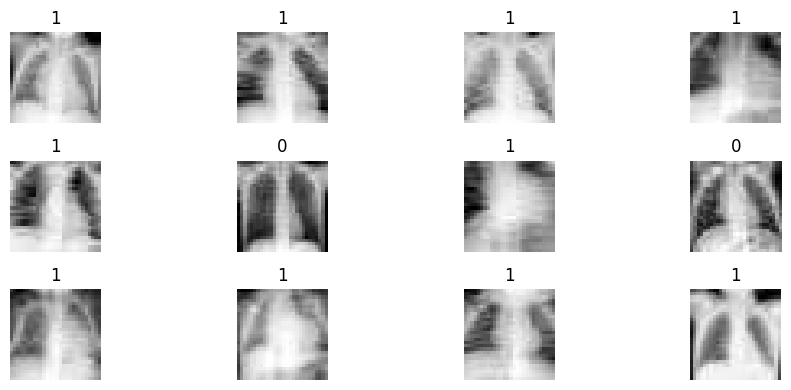

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [7]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5877 | val_acc=0.7424 | val_auc=0.5249
Epoch 02 | train_loss=0.5622 | val_acc=0.7424 | val_auc=0.7829
Epoch 03 | train_loss=0.5250 | val_acc=0.7424 | val_auc=0.8911
Epoch 04 | train_loss=0.4506 | val_acc=0.7481 | val_auc=0.9326
Epoch 05 | train_loss=0.3660 | val_acc=0.8492 | val_auc=0.9462
Epoch 06 | train_loss=0.2833 | val_acc=0.8855 | val_auc=0.9527
Epoch 07 | train_loss=0.2331 | val_acc=0.8740 | val_auc=0.9600
Epoch 08 | train_loss=0.2328 | val_acc=0.9160 | val_auc=0.9684


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


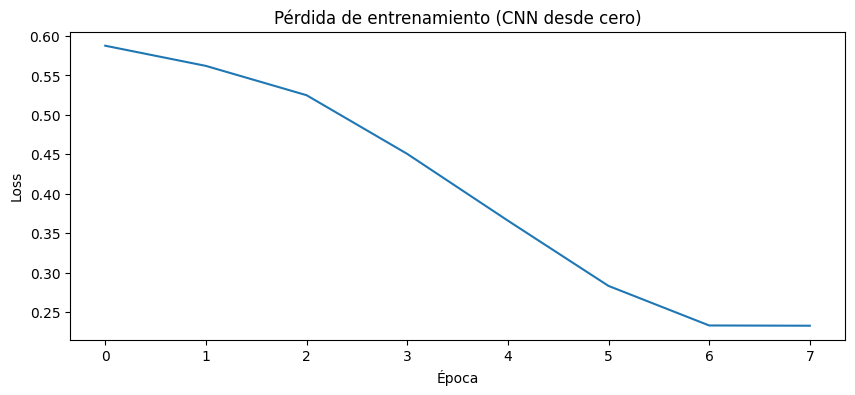

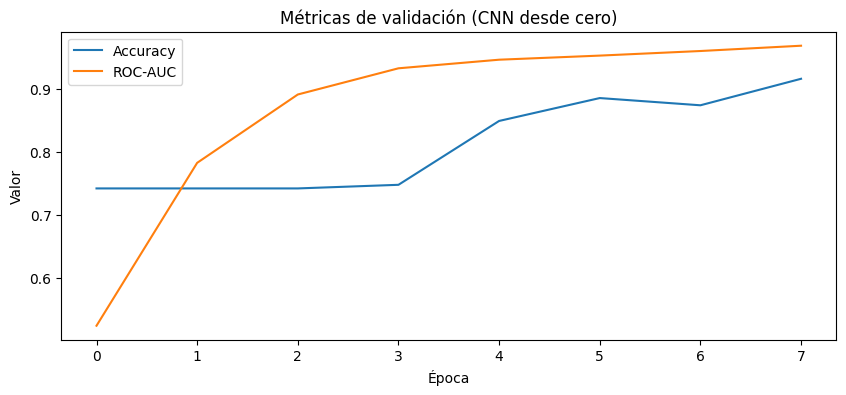

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [11]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8878
Test ROC-AUC:  0.9491

              precision    recall  f1-score   support

           0     0.8868    0.8034    0.8430       234
           1     0.8883    0.9385    0.9127       390

    accuracy                         0.8878       624
   macro avg     0.8876    0.8709    0.8779       624
weighted avg     0.8878    0.8878    0.8866       624



array([[188,  46],
       [ 24, 366]])

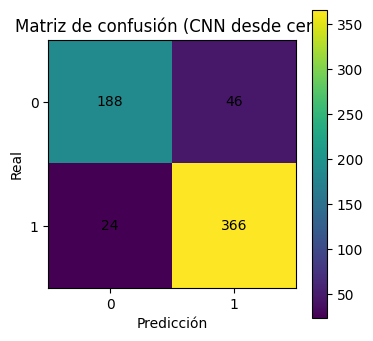

In [12]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [13]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [14]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5896 | val_acc=0.7424 | val_auc=0.5196
Epoch 02 | train_loss=0.5715 | val_acc=0.7424 | val_auc=0.5878
Epoch 03 | train_loss=0.5688 | val_acc=0.7424 | val_auc=0.6411
Epoch 04 | train_loss=0.5534 | val_acc=0.7424 | val_auc=0.7091
Epoch 05 | train_loss=0.5004 | val_acc=0.7366 | val_auc=0.7671
Epoch 06 | train_loss=0.4459 | val_acc=0.7920 | val_auc=0.8555


### 6.1. Comparación rápida


In [15]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8878 | test_auc=0.9491
Con augmentation  | test_acc=0.7724 | test_auc=0.8528


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [16]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [17]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.4997 | val_acc=0.7863 | val_auc=0.8403
Stage1 Epoch 02 | train_loss=0.3354 | val_acc=0.8569 | val_auc=0.9177
Stage1 Epoch 03 | train_loss=0.2942 | val_acc=0.8473 | val_auc=0.9292
Stage1 Epoch 04 | train_loss=0.2703 | val_acc=0.8645 | val_auc=0.9363


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [19]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [20]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.1596 | val_acc=0.9256 | val_auc=0.9864
Stage2 Epoch 02 | train_loss=0.0992 | val_acc=0.9599 | val_auc=0.9904
Stage2 Epoch 03 | train_loss=0.0830 | val_acc=0.9466 | val_auc=0.9915
Stage2 Epoch 04 | train_loss=0.0652 | val_acc=0.9637 | val_auc=0.9928


### 7.3. Evaluación en test del modelo con transfer learning


In [21]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8478 | test_auc=0.9756

              precision    recall  f1-score   support

           0     0.9929    0.5983    0.7467       234
           1     0.8054    0.9974    0.8912       390

    accuracy                         0.8478       624
   macro avg     0.8991    0.7979    0.8189       624
weighted avg     0.8757    0.8478    0.8370       624



array([[140,  94],
       [  1, 389]])

### 7.4. Comparación global (resumen)


In [22]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8878 | auc=0.9491
CNN desde cero (con aug)  | acc=0.7724 | auc=0.8528
Transfer learning (ResNet) | acc=0.8478 | auc=0.9756


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [23]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


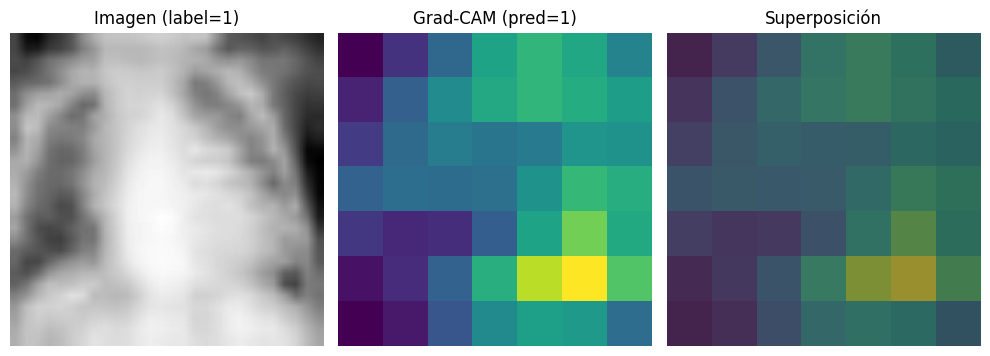

In [24]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [25]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

.

.

.

.

.

.

.

.

.



## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


#  4. Cambia el dataset dentro de medmnist (por ejemplo: breastmnist, dermamnist) y adapta el pipeline.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

import medmnist
from medmnist import INFO

In [8]:
data_flag = "dermamnist"

info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

print("Dataset:", data_flag)
print("Clases:", info["label"])
print("Canales:", info["n_channels"])

Dataset: dermamnist
Clases: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
Canales: 3


Transformaciones

In [10]:
transform_train = T.Compose([
    T.RandomRotation(10),
    T.RandomAffine(0, translate=(0.05, 0.05)),
    T.ToTensor()
])

transform_test = T.Compose([
    T.ToTensor()
])

Datasets

In [11]:
train_dataset = DataClass(split="train", transform=transform_train, download=True)
val_dataset   = DataClass(split="val", transform=transform_test, download=True)
test_dataset  = DataClass(split="test", transform=transform_test, download=True)

100%|██████████| 19.7M/19.7M [00:02<00:00, 9.69MB/s]


DataLoaders

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128)
test_loader  = DataLoader(test_dataset, batch_size=128)

Modelo CNN

In [13]:
class CNN(nn.Module):
    def __init__(self, num_classes, in_channels):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNN(
    num_classes=len(info["label"]),
    in_channels=info["n_channels"]
).to(device)

Loss + Optimizer + Scheduler

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

Train

In [15]:
def train_epoch(model, loader):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.squeeze(1).long().to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)

Evaluate (BINARIO, MULTICLASE)

In [16]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x = x.to(device)
        y = y.squeeze(1).long().to(device)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.append(y.cpu().numpy())
        y_pred.append(preds.cpu().numpy())
        y_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    acc = accuracy_score(y_true, y_pred)

    # binario vs multiclase
    if y_prob.shape[1] == 2:
        auc = roc_auc_score(y_true, y_prob[:,1])
    else:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr")

    return acc, auc, y_true, y_pred, y_prob

Training loop con Early Stopping

In [25]:
epochs = 20
best_auc = 0
patience = 5
counter = 0

history = {"loss": [], "acc": [], "auc": []}

for epoch in range(epochs):
    loss = train_epoch(model, train_loader)
    acc, auc, _, _, _ = evaluate(model, val_loader)

    scheduler.step(auc)

    history["loss"].append(loss)
    history["acc"].append(acc)
    history["auc"].append(auc)

    lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:02d} | Loss={loss:.4f} | Acc={acc:.4f} | AUC={auc:.4f} | LR={lr:.6f}")

    if auc > best_auc:
        best_auc = auc
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch 01 | Loss=0.6920 | Acc=0.7238 | AUC=0.8971 | LR=0.000500
Epoch 02 | Loss=0.6817 | Acc=0.7448 | AUC=0.9198 | LR=0.000500
Epoch 03 | Loss=0.6790 | Acc=0.7308 | AUC=0.9210 | LR=0.000500
Epoch 04 | Loss=0.6742 | Acc=0.7398 | AUC=0.9226 | LR=0.000500
Epoch 05 | Loss=0.6727 | Acc=0.6899 | AUC=0.9028 | LR=0.000500
Epoch 06 | Loss=0.6737 | Acc=0.7129 | AUC=0.9135 | LR=0.000500
Epoch 07 | Loss=0.6755 | Acc=0.7328 | AUC=0.9264 | LR=0.000500
Epoch 08 | Loss=0.6649 | Acc=0.7478 | AUC=0.9116 | LR=0.000500
Epoch 09 | Loss=0.6606 | Acc=0.7717 | AUC=0.9240 | LR=0.000500
Epoch 10 | Loss=0.6582 | Acc=0.7557 | AUC=0.9192 | LR=0.000500
Epoch 11 | Loss=0.6603 | Acc=0.7298 | AUC=0.9236 | LR=0.000250
Epoch 12 | Loss=0.6431 | Acc=0.7567 | AUC=0.9255 | LR=0.000250
Early stopping


Test final

In [18]:
model.load_state_dict(torch.load("best_model.pth"))

acc, auc, y_true, y_pred, y_prob = evaluate(model, test_loader)

print("\nTEST RESULTS")
print("Accuracy:", acc)
print("AUC:", auc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


TEST RESULTS
Accuracy: 0.7316708229426434
AUC: 0.9085707600447245

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.14      0.23        66
           1       0.50      0.30      0.38       103
           2       0.45      0.50      0.48       220
           3       0.00      0.00      0.00        23
           4       0.53      0.25      0.34       223
           5       0.80      0.94      0.86      1341
           6       0.80      0.14      0.24        29

    accuracy                           0.73      2005
   macro avg       0.53      0.32      0.36      2005
weighted avg       0.70      0.73      0.70      2005



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Curvas

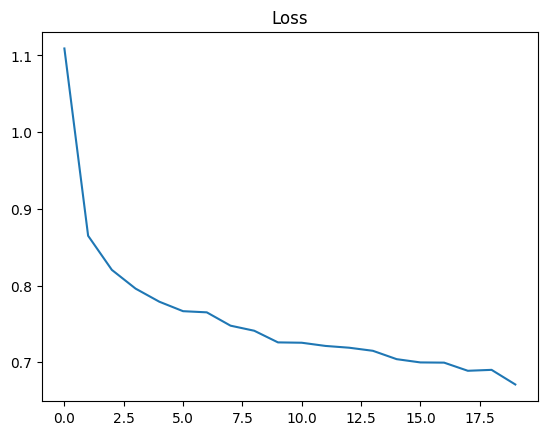

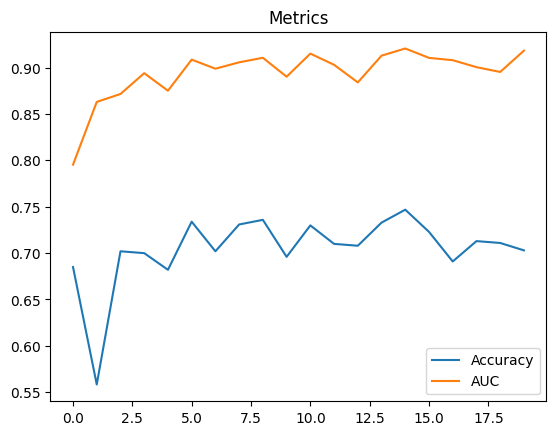

In [19]:
plt.plot(history["loss"])
plt.title("Loss")
plt.show()

plt.plot(history["acc"], label="Accuracy")
plt.plot(history["auc"], label="AUC")
plt.legend()
plt.title("Metrics")
plt.show()

ROC (binario)

In [20]:
if y_prob.shape[1] == 2:
    fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])

    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

Confusion Matrix

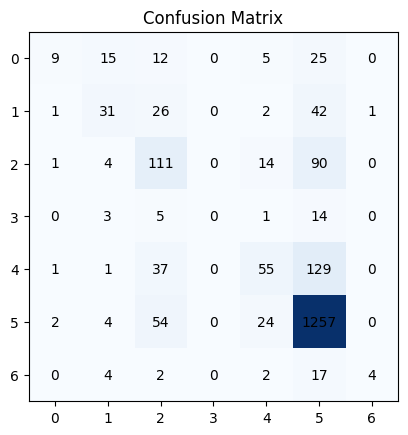

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()

In [22]:
import matplotlib.pyplot as plt

def show_batch(dataset, info, n=12):
    plt.figure(figsize=(10,5))

    for i in range(n):
        x, y = dataset[i]

        img = x.permute(1, 2, 0)  # (C,H,W) → (H,W,C)

        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.title(info["label"][str(int(y.item()))])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

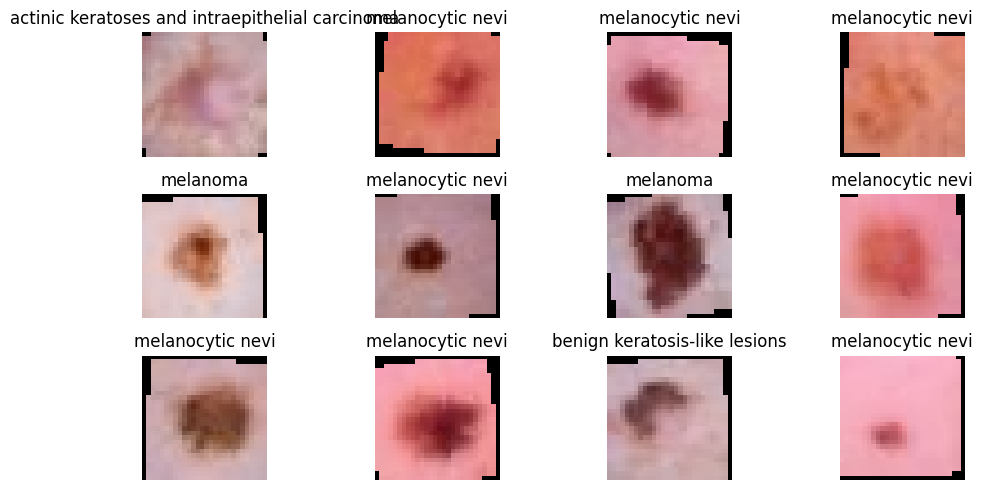

In [23]:
show_batch(train_dataset, info, n=12)

RESULTADOS:

Este modelo alcanzó un 73% de precisión, lo cual es aceptable, pero tiene un AUC de 0.90, lo que indica que es muy capaz de distinguir entre diferentes tipos de lesiones. Sin embargo, sufre de desbalance: como tiene muchísimas imágenes de "lunares comunes" (clase 5), aprendió a clasificarlos perfecto, pero tiende a ignorar o fallar en las enfermedades que tienen pocas fotos (clase 3).